In [1]:
import os
print(os.getcwd())

C:\Users\HP\Documents


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\HP\Documents\GMSL_TPJAOS_5.2.txt', 
                  comment='H',
                  sep=r'\s+',
                  header=None)

df.columns = ['altimeter_type', 'cycle_number', 'year', 
              'num_observations', 'num_weighted_obs',
              'gmsl_no_gia', 'std_no_gia', 'smooth_no_gia',
              'gmsl_gia', 'std_gia', 'smooth_gia',
              'smooth_gia_no_seasonal', 'smooth_no_gia_no_seasonal']

print("Shape:", df.shape)
print(df.head())

Shape: (1191, 13)
   altimeter_type  cycle_number         year  num_observations  \
0               0            11  1993.011526            466881   
1               0            12  1993.038692            459563   
2               0            13  1993.065858            402996   
3               0            14  1993.093025            462894   
4               0            15  1993.120191            460498   

   num_weighted_obs  gmsl_no_gia  std_no_gia  smooth_no_gia  gmsl_gia  \
0         338409.69       -37.91       89.01         -37.67    -37.90   
1         333609.59       -40.95       89.95         -39.07    -40.94   
2         292736.50       -41.09       86.90         -39.65    -41.07   
3         336670.31       -43.38       88.73         -39.40    -43.36   
4         332486.09       -38.66       89.87         -38.51    -38.63   

   std_gia  smooth_gia  smooth_gia_no_seasonal  smooth_no_gia_no_seasonal  
0    89.01      -37.66                  -37.64                     -37

In [5]:
# Replace bad values with NaN
df = df.replace(99900.000, np.nan)

# Add decade column
df['decade'] = (df['year'].astype(int) // 10) * 10

# Add era column
df['era'] = pd.cut(df['year'], 
                   bins=[1992, 2000, 2010, 2020, 2026],
                   labels=['1990s', '2000s', '2010s', '2020s'])

print("Missing values:")
print(df.isnull().sum())
print("\nShape:", df.shape)

Missing values:
altimeter_type               0
cycle_number                 0
year                         0
num_observations             0
num_weighted_obs             0
gmsl_no_gia                  0
std_no_gia                   0
smooth_no_gia                0
gmsl_gia                     0
std_gia                      0
smooth_gia                   0
smooth_gia_no_seasonal       0
smooth_no_gia_no_seasonal    0
decade                       0
era                          0
dtype: int64

Shape: (1191, 15)


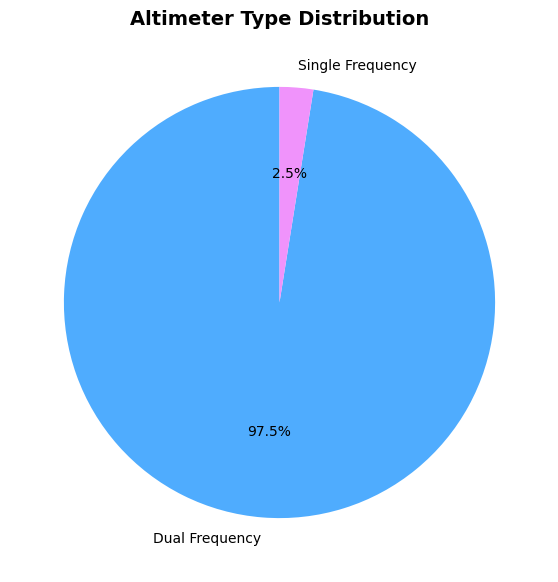

In [6]:
plt.figure(figsize=(7,7))
altimeter_counts = df['altimeter_type'].value_counts()
altimeter_labels = ['Dual Frequency' if x == 0 else 'Single Frequency' 
                    for x in altimeter_counts.index]
plt.pie(altimeter_counts, labels=altimeter_labels, autopct='%1.1f%%',
        colors=['#4facfe', '#f093fb'], startangle=90)
plt.title('Altimeter Type Distribution', fontsize=14, fontweight='bold')
plt.show()

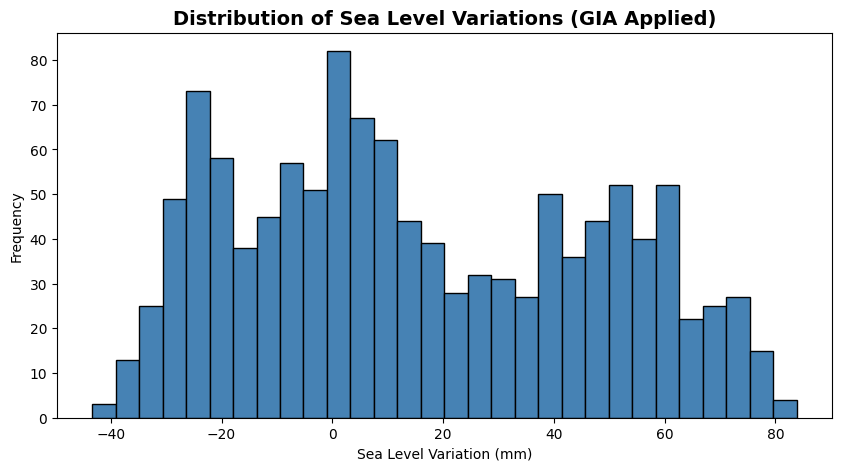

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df['gmsl_gia'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Sea Level Variations (GIA Applied)', fontsize=14, fontweight='bold')
plt.xlabel('Sea Level Variation (mm)')
plt.ylabel('Frequency')
plt.show()

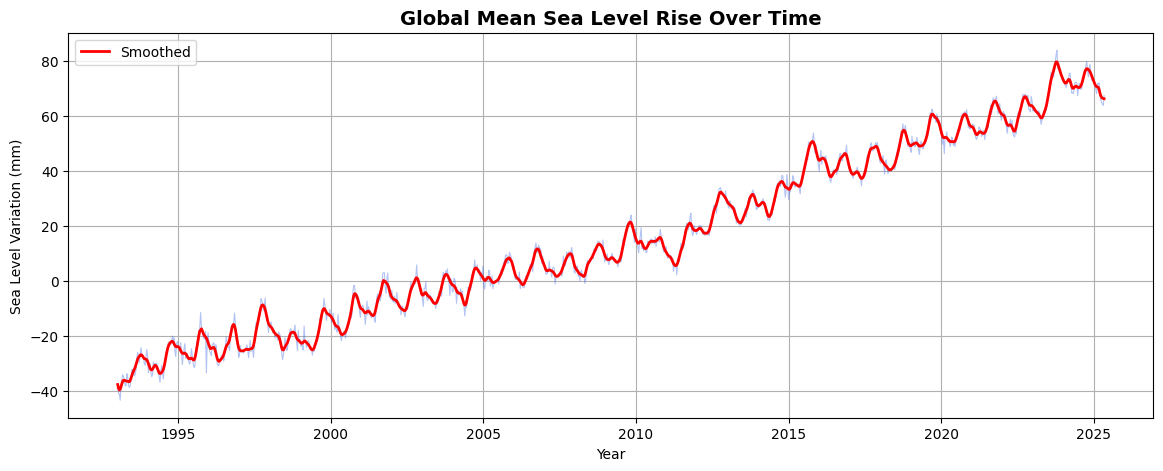

In [8]:
plt.figure(figsize=(14,5))
plt.plot(df['year'], df['gmsl_gia'], color='royalblue', alpha=0.4, linewidth=0.8)
plt.plot(df['year'], df['smooth_gia'], color='red', linewidth=2, label='Smoothed')
plt.title('Global Mean Sea Level Rise Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sea Level Variation (mm)')
plt.legend()
plt.grid(True)
plt.show()

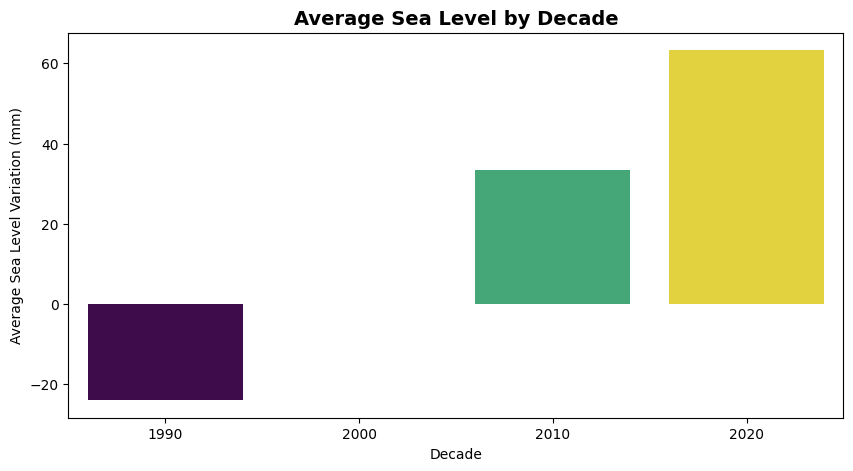

In [9]:
decade_avg = df.groupby('decade')['gmsl_gia'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=decade_avg, x='decade', y='gmsl_gia', 
            hue='decade', palette='viridis', legend=False)
plt.title('Average Sea Level by Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Average Sea Level Variation (mm)')
plt.show()

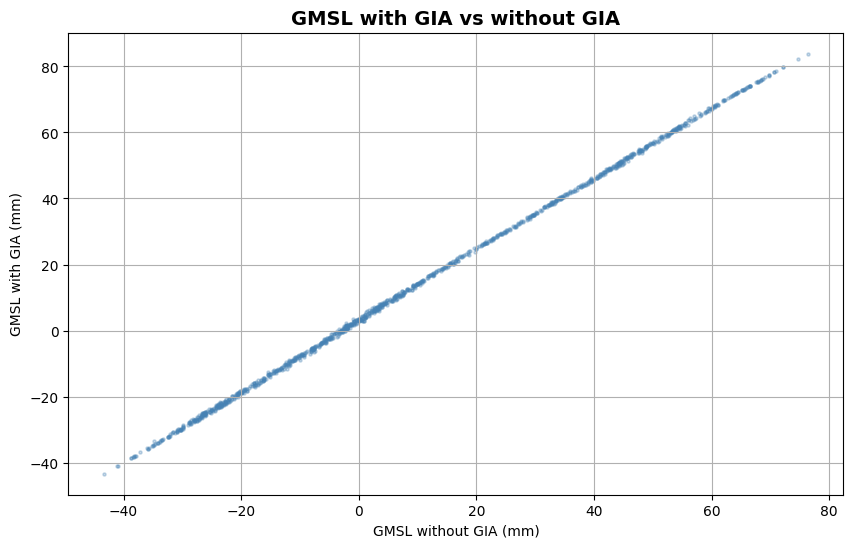

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(df['gmsl_no_gia'], df['gmsl_gia'], alpha=0.3, color='steelblue', s=5)
plt.title('GMSL with GIA vs without GIA', fontsize=14, fontweight='bold')
plt.xlabel('GMSL without GIA (mm)')
plt.ylabel('GMSL with GIA (mm)')
plt.grid(True)
plt.show()

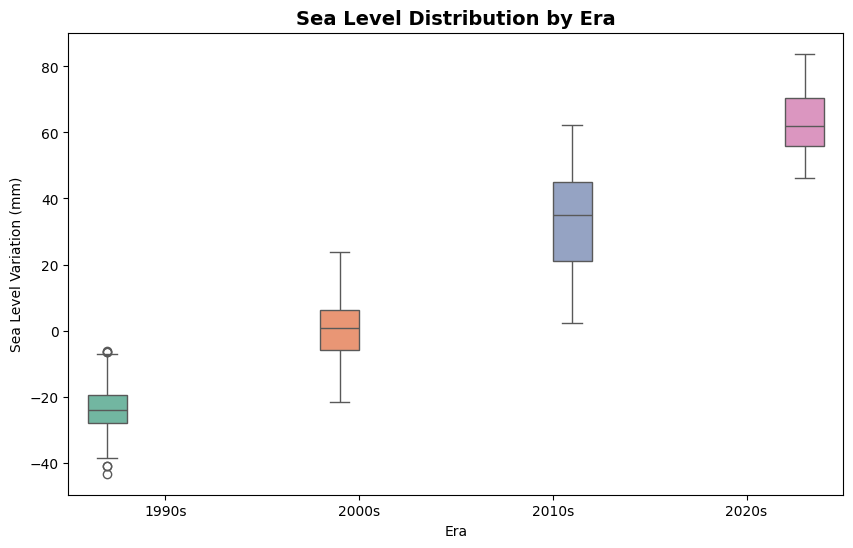

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='era', y='gmsl_gia', 
            hue='era', palette='Set2', legend=False)
plt.title('Sea Level Distribution by Era', fontsize=14, fontweight='bold')
plt.xlabel('Era')
plt.ylabel('Sea Level Variation (mm)')
plt.show()

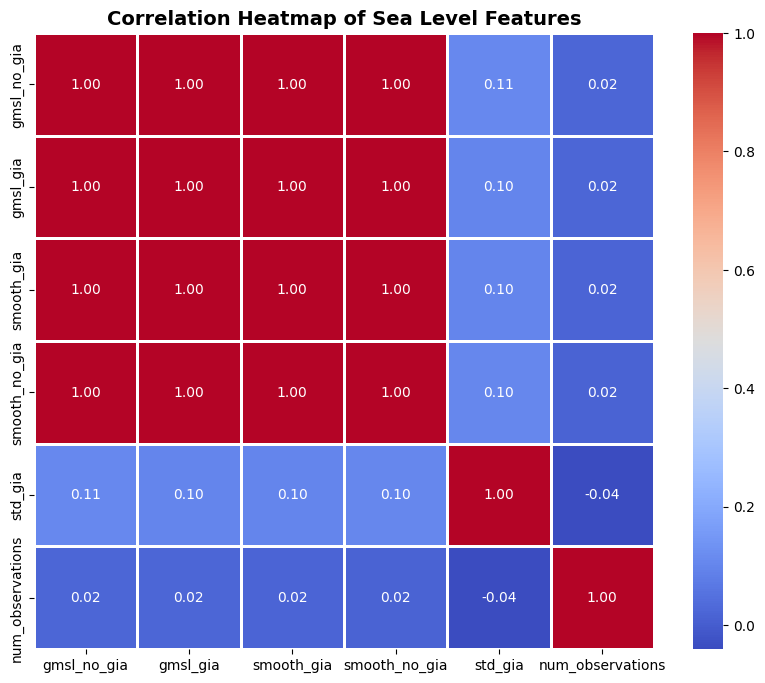

In [12]:
plt.figure(figsize=(10,8))
corr = df[['gmsl_no_gia', 'gmsl_gia', 'smooth_gia', 
           'smooth_no_gia', 'std_gia', 'num_observations']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap of Sea Level Features', fontsize=14, fontweight='bold')
plt.show()

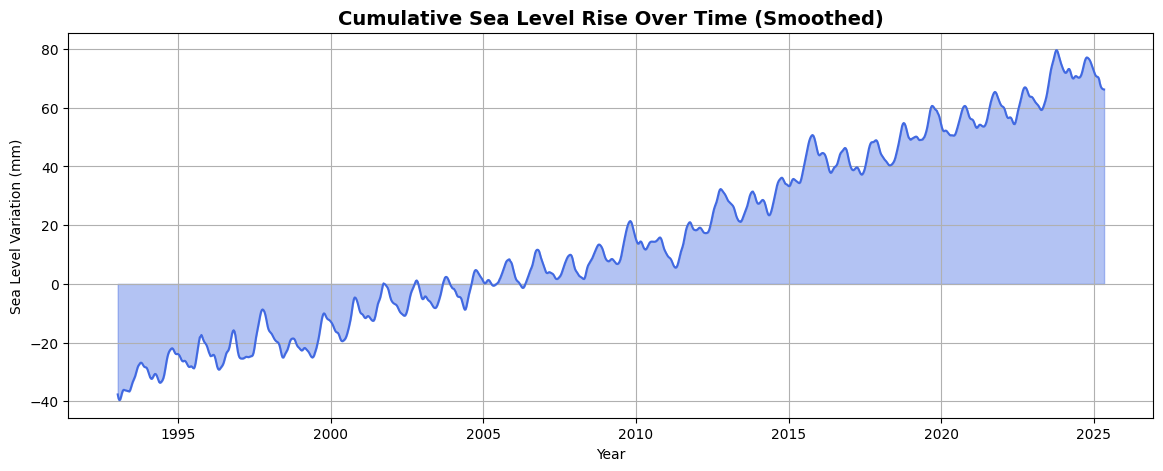

In [13]:
plt.figure(figsize=(14,5))
plt.fill_between(df['year'], df['smooth_gia'], alpha=0.4, color='royalblue')
plt.plot(df['year'], df['smooth_gia'], color='royalblue', linewidth=1.5)
plt.title('Cumulative Sea Level Rise Over Time (Smoothed)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sea Level Variation (mm)')
plt.grid(True)
plt.show()

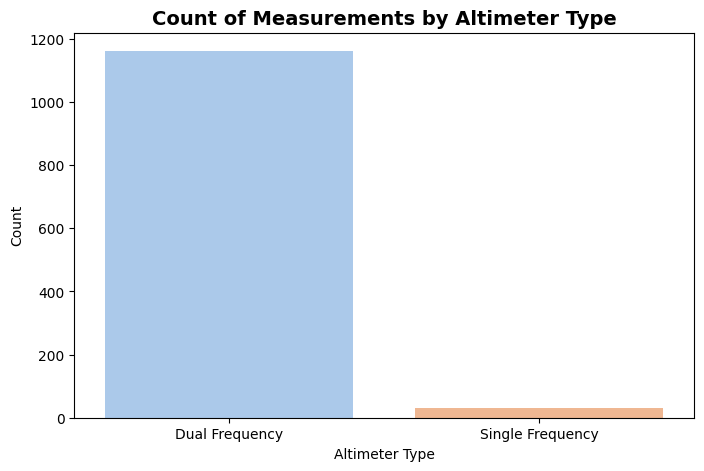

In [14]:
plt.figure(figsize=(8,5))
df['altimeter_label'] = df['altimeter_type'].apply(
    lambda x: 'Dual Frequency' if x == 0 else 'Single Frequency')
sns.countplot(data=df, x='altimeter_label', 
              hue='altimeter_label', palette='pastel', legend=False)
plt.title('Count of Measurements by Altimeter Type', fontsize=14, fontweight='bold')
plt.xlabel('Altimeter Type')
plt.ylabel('Count')
plt.show()

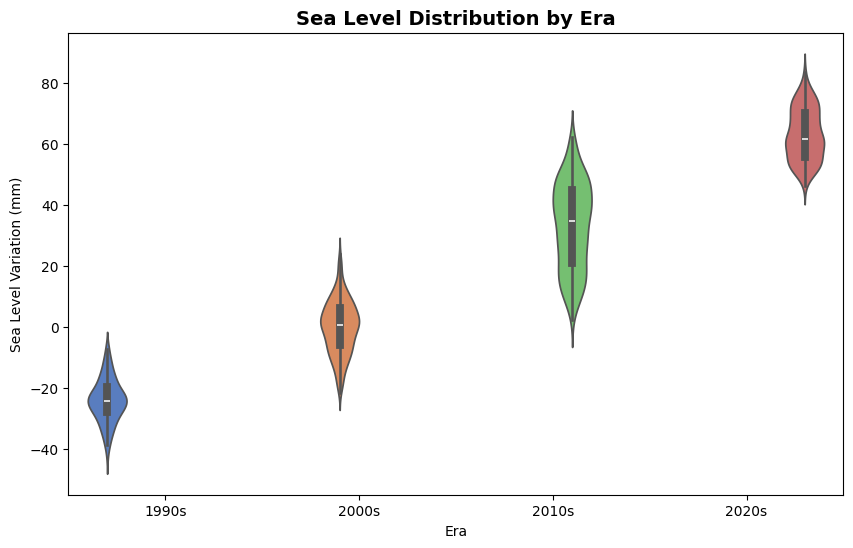

In [15]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='era', y='gmsl_gia',
               hue='era', palette='muted', legend=False)
plt.title('Sea Level Distribution by Era', fontsize=14, fontweight='bold')
plt.xlabel('Era')
plt.ylabel('Sea Level Variation (mm)')
plt.show()

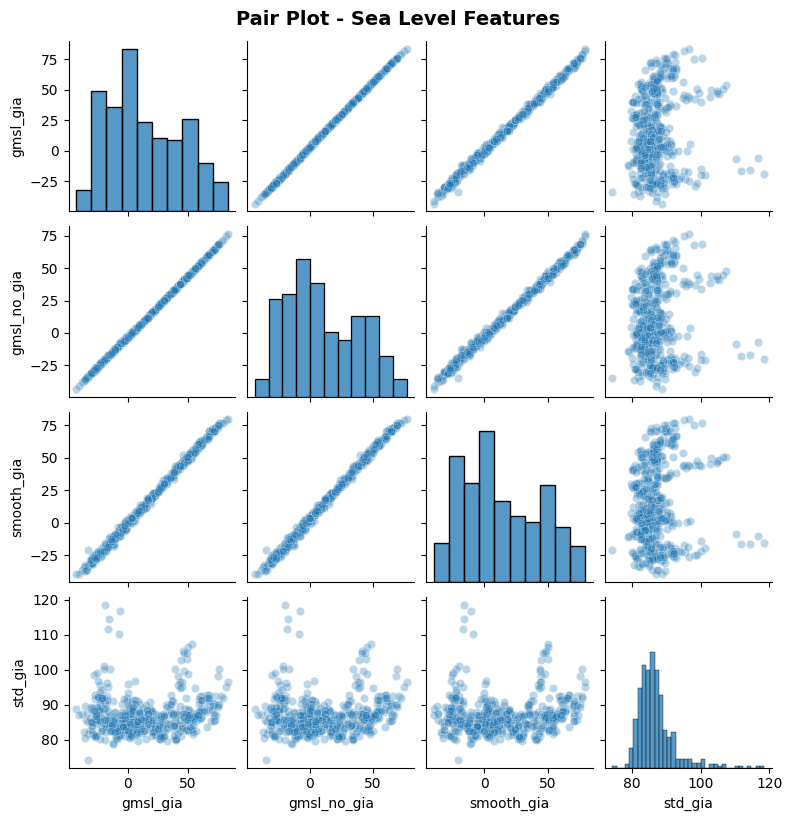

In [16]:
pair_data = df[['gmsl_gia', 'gmsl_no_gia', 'smooth_gia', 'std_gia']].dropna().sample(500, random_state=42)
pg = sns.pairplot(pair_data, plot_kws={'alpha': 0.3}, height=2)
pg.fig.suptitle('Pair Plot - Sea Level Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

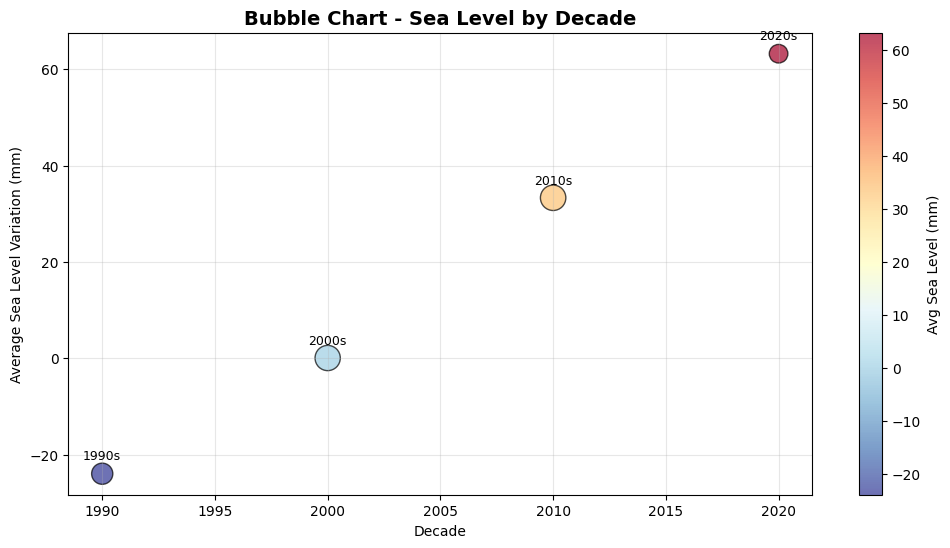

In [17]:
decade_stats = df.groupby('decade').agg(
    avg_sea_level=('gmsl_gia', 'mean'),
    avg_std=('std_gia', 'mean'),
    total_obs=('num_observations', 'sum')
).reset_index()

plt.figure(figsize=(12,6))
scatter = plt.scatter(
    decade_stats['decade'],
    decade_stats['avg_sea_level'],
    s=decade_stats['total_obs'] / 500000,
    c=decade_stats['avg_sea_level'],
    cmap='RdYlBu_r',
    alpha=0.7,
    edgecolors='black'
)
for _, row in decade_stats.iterrows():
    plt.annotate(f"{int(row['decade'])}s", 
                (row['decade'], row['avg_sea_level']),
                textcoords='offset points',
                xytext=(0,10), ha='center', fontsize=9)
plt.colorbar(scatter, label='Avg Sea Level (mm)')
plt.title('Bubble Chart - Sea Level by Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Average Sea Level Variation (mm)')
plt.grid(True, alpha=0.3)
plt.show()

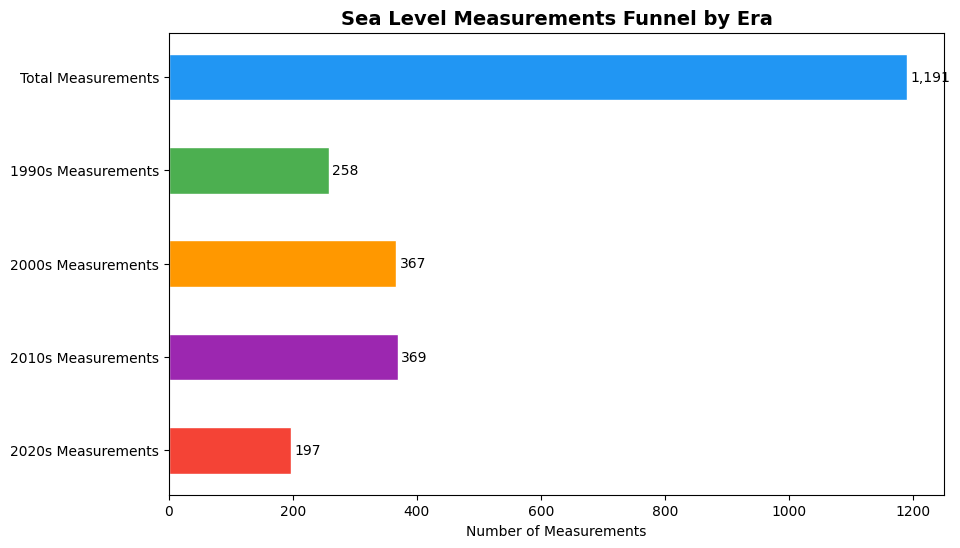

In [18]:
era_counts = df.groupby('era')['gmsl_gia'].count().reset_index()

stages = {
    'Total Measurements': len(df),
    '1990s Measurements': len(df[df['era'] == '1990s']),
    '2000s Measurements': len(df[df['era'] == '2000s']),
    '2010s Measurements': len(df[df['era'] == '2010s']),
    '2020s Measurements': len(df[df['era'] == '2020s'])
}

labels = list(stages.keys())
values = list(stages.values())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

plt.figure(figsize=(10,6))
bars = plt.barh(labels, values, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.title('Sea Level Measurements Funnel by Era', fontsize=14, fontweight='bold')
plt.xlabel('Number of Measurements')
plt.gca().invert_yaxis()
plt.show()